In [82]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import train_test_val_split, evaluate_finetuned_model
from sklearn.metrics import classification_report

def plot_predicted_vs_true(y_true, y_pred, ax, title):
    ax.scatter(y_true, y_pred)
    # ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel("True Yield kg/H")
    ax.set_ylabel("Predicted Yield kg/H")
    ax.set_title(title)

In [83]:
# Dataset Parameters
composite_window="month"
unique_id_column="Field_ID"
old_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_05112025/polygons/{composite_window}/"
data_2023_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_24022026/polygons/{composite_window}/"
new_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_04022026/polygons/{composite_window}/"

In [84]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2021-07-01", "2021-11-30"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2022-07-01", "2022-11-30"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(data_2023_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2023-07-01", "2023-11-30"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(new_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2025-07-01", "2025-11-30"],
)


  0%|          | 0/1 [00:00<?, ?it/s]

/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithC

#### Data investigation

In [85]:
# Print min and max of yield distribution for each year
th = 6000
extractions_2022 = extractions_2022[extractions_2022['Yield kg/H'] < th].reset_index(drop=True)
datasets = [extractions_2021, extractions_2022, extractions_2023, extractions_2025]
years = [2021, 2022, 2023, 2025]

for i, (dataset, year) in enumerate(zip(datasets, years)):
    min_yield = dataset['Yield kg/H'].min()
    max_yield = dataset['Yield kg/H'].max()
    print(f"Year {year}: Min = {min_yield:.2f} kg/H, Max = {max_yield:.2f} kg/H")


Year 2021: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2022: Min = 226.60 kg/H, Max = 4792.60 kg/H
Year 2023: Min = 901.10 kg/H, Max = 6352.20 kg/H
Year 2025: Min = 785.55 kg/H, Max = 2830.45 kg/H


In [86]:
for y in years:
    datasets[years.index(y)]['year'] = y
extractions = pd.concat(datasets, ignore_index=True)
target_column = "Yield kg/H"
extractions["Field_ID_year"] = extractions['Field_ID'] + "_" + extractions['year'].astype(str)
extractions['REGION'] = extractions['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
extractions['DISTRICT'] = extractions['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
extractions['COMMUNITY'] = extractions['COMMUNITY'].apply(lambda x: x.upper())

In [87]:
extractions[unique_id_column] = extractions[unique_id_column].astype(str) + "_" + extractions['year'].astype(str)

In [88]:
import matplotlib.pyplot as plt
import numpy as np

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram with bars next to each other
    bin_edges = np.histogram_bin_edges(
        pd.concat([train_df[target_column], test_df[target_column], val_df[target_column]]).dropna(), bins=20
    )

    width = 0.25
    # Plot histogram for Yield kg/H for each split using the same bin edges
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        hist, _ = np.histogram(data[target_column].dropna(), bins=bin_edges)
        # Use bin centers for bar positions
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        axes[0, 2].bar(bin_centers + i*width - width, hist, width=width, alpha=0.7, color=color, label=label, align='center')
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Bin mean yield and std plot
    bin_labels = ['Low', 'High'] if 'bin' in train_df.columns else train_df['bin'].unique().astype(str)
    x = np.arange(len(bin_labels))
    for idx, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        bin_means = data.groupby('bin')['Yield kg/H'].mean().reindex([0,1], fill_value=0)
        bin_stds = data.groupby('bin')['Yield kg/H'].std().reindex([0,1], fill_value=0)
        axes[1, 2].bar(x + idx*width, bin_means.values, width=width, yerr=bin_stds.values, capsize=5, color=color, alpha=0.8, label=label)

    axes[1, 2].set_title('Bin Mean Yield ± Std')
    axes[1, 2].set_xlabel('Bin')
    axes[1, 2].set_ylabel('Mean Yield (kg/H)')
    axes[1, 2].set_xticks(x + width)
    axes[1, 2].set_xticklabels(bin_labels)
    axes[1, 2].legend()
    # # Remove the empty subplot
    # axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

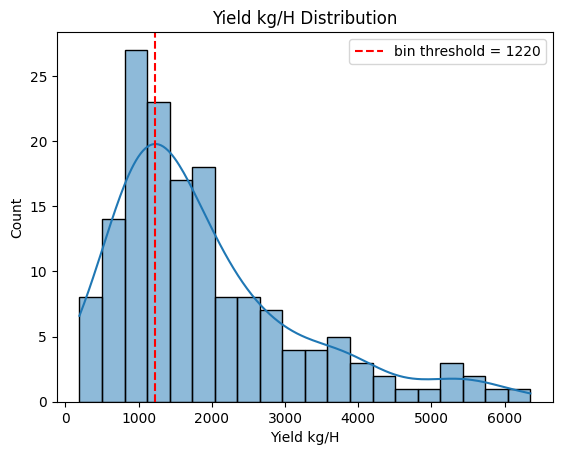

In [89]:
import seaborn as sns
bin_th = 1220
sns.histplot(extractions['Yield kg/H'], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()

### Binarize target

In [90]:
from sklearn.model_selection import train_test_split

# Create bins for stratification based on the parent group's median yield
extractions['bin'] = extractions[target_column].apply(lambda x: 0 if x < bin_th else 1)

# Filter out yield bins with less than 3 samples to avoid stratification issues
bin_counts = extractions['bin'].value_counts()
valid_bins = bin_counts[bin_counts >= 3].index
extractions_filtered = extractions[extractions['bin'].isin(valid_bins)]

# Compute mean and std of yield for each bin and add as columns
bin_stats = extractions.groupby('bin')[target_column].agg(['mean', 'std']).rename(columns={'mean': 'bin_mean_yield', 'std': 'bin_std_yield'})
extractions = extractions.merge(bin_stats, left_on='bin', right_index=True, how='left')

print(f"Original parent groups: {len(extractions)}")
print(f"After filtering bins with <3 samples: {len(extractions_filtered)}")
print(f"Removed {len(extractions) - len(extractions_filtered)} parent groups")

# Get unique parentnames as our splitting units (from filtered data)
parentnames = extractions_filtered[unique_id_column].unique().tolist()
yield_bins = extractions_filtered['bin'].values

# First split: 80% train, 20% temp (for val and test)
train_parents, temp_parents = train_test_split(
    parentnames,
    train_size=0.8,
    stratify=yield_bins,
    random_state=42
)

# Get yield bins for temp parents and check if they still have enough samples for stratification
temp_bins = extractions_filtered[extractions_filtered[unique_id_column].isin(temp_parents)]['bin'].values
temp_bin_counts = pd.Series(temp_bins).value_counts()

# Check if any bin in temp set has less than 2 samples (minimum for stratification)
if (temp_bin_counts < 2).any():
    print("Warning: Some bins in temp set have <2 samples. Using random split instead of stratified split for val/test.")
    # Second split: split temp randomly into 50-50 for val and test
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        random_state=42
    )
else:
    # Second split: split temp into 50-50 for val and test with stratification
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        stratify=temp_bins,
        random_state=42
    )

# Create the final datasets by filtering on parentname
train_df = extractions[extractions[unique_id_column].isin(train_parents)]
val_df = extractions[extractions[unique_id_column].isin(val_parents)]
test_df = extractions[extractions[unique_id_column].isin(test_parents)]

print(f"Train set size: {len(train_df)} ({len(train_df)/len(extractions)*100:.1f}%)")
print(f"Validation set size: {len(val_df)} ({len(val_df)/len(extractions)*100:.1f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(extractions)*100:.1f}%)")

# Verify no parentname overlap
assert len(set(train_df[unique_id_column]) & set(val_df[unique_id_column])) == 0
assert len(set(train_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
assert len(set(val_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
print(f"✓ No {unique_id_column} overlap between splits")

Original parent groups: 157
After filtering bins with <3 samples: 157
Removed 0 parent groups
Train set size: 125 (79.6%)
Validation set size: 16 (10.2%)
Test set size: 16 (10.2%)
✓ No Field_ID overlap between splits


/tmp/ipykernel_344022/529029868.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])


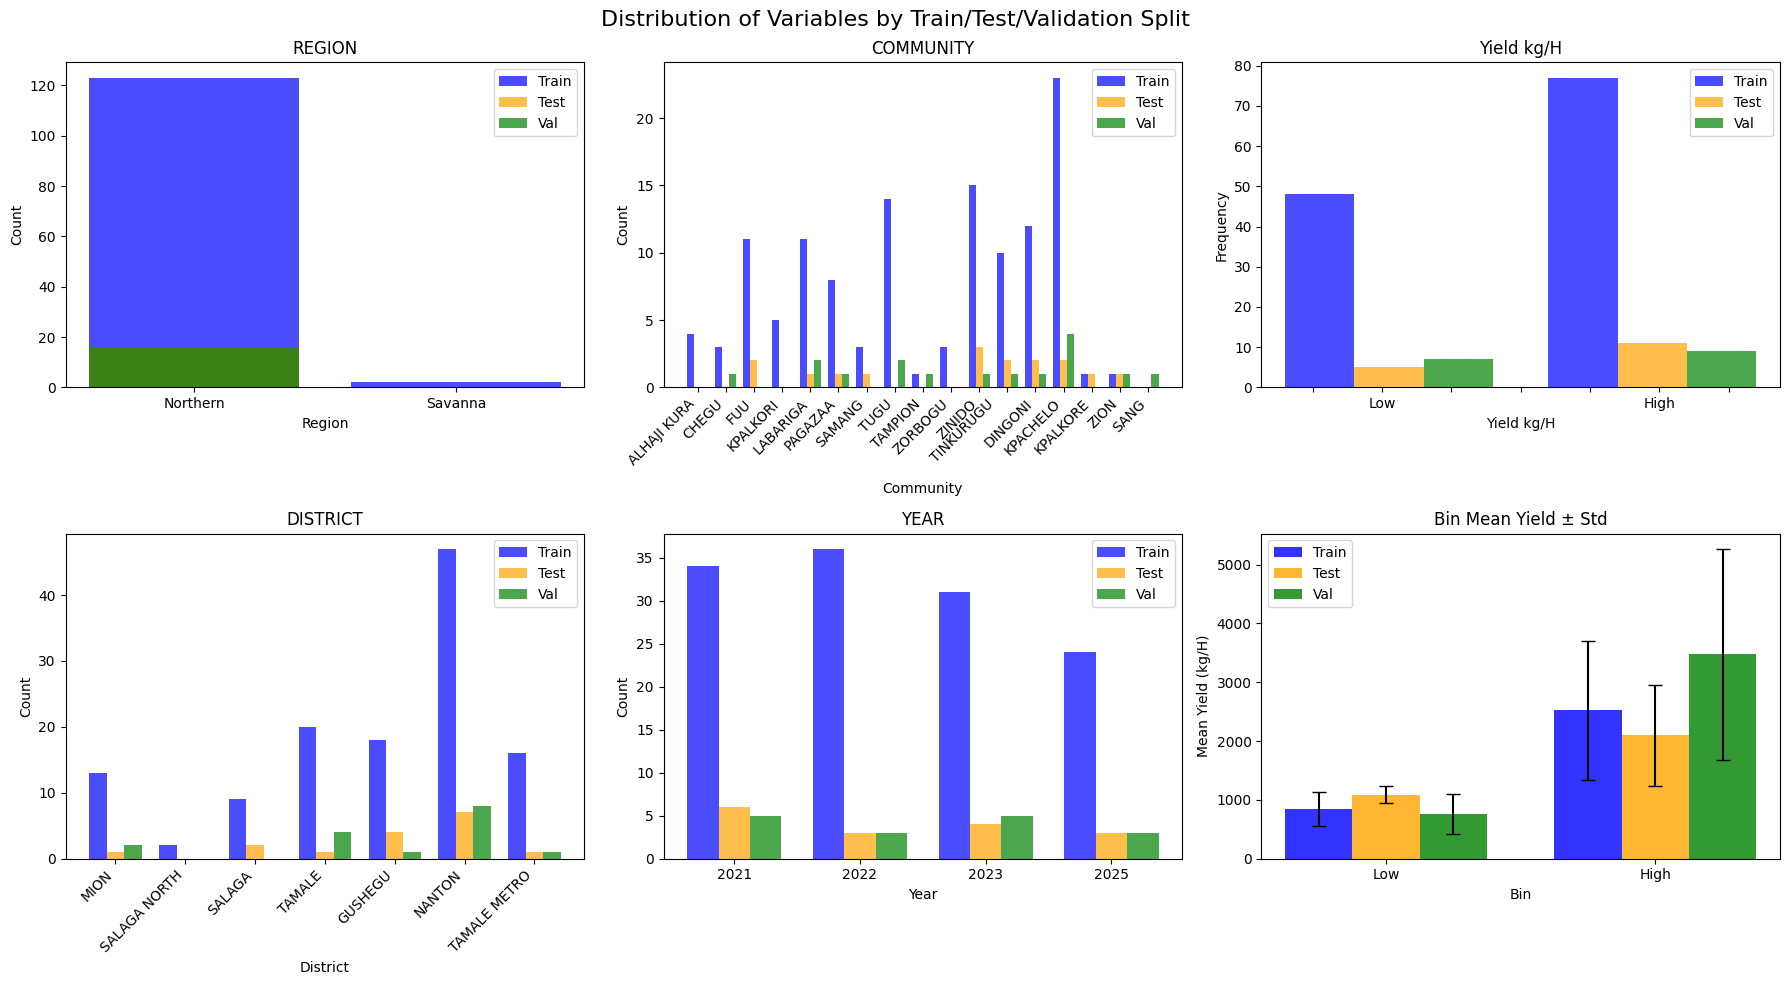

In [91]:
plot_distribution(train_df, test_df, val_df, 'bin')

##### Random Forest

In [92]:
target_column = 'bin'
# predict mean and evaluate based on std 

In [93]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [94]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [95]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])

# Early stopping using validation set. this allows selecting the best n_estimators
best_val_score = -float('inf')
best_n_estimators = 10
patience = 5
no_improve = 0

for n_estimators in range(10, 101, 10):
    rf_pipe.named_steps['rf'].n_estimators = n_estimators
    rf_pipe.fit(X_train, y_train)
    val_score = rf_pipe.score(X_val, y_val)
    if val_score > best_val_score:
        best_val_score = val_score
        best_n_estimators = n_estimators
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= patience:
        break

# Refit with best n_estimators
rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=best_n_estimators,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])
rf_pipe.fit(X_train, y_train)

preds_train_rf = rf_pipe.predict(X_train)
preds_val_rf = rf_pipe.predict(X_val)
preds_test_rf = rf_pipe.predict(X_test)

##### Catboost 

In [ ]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
)

cat_clf.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20
)

preds_train_cb = cat_clf.predict(X_train) 
preds_val_cb = cat_clf.predict(X_val)
preds_test_cb = cat_clf.predict(X_test)


0:	learn: 0.6892131	test: 0.6931608	best: 0.6931608 (0)	total: 3.18ms	remaining: 1.59s
100:	learn: 0.4377615	test: 0.6098586	best: 0.6098286 (98)	total: 167ms	remaining: 659ms
200:	learn: 0.3090586	test: 0.5866180	best: 0.5864244 (199)	total: 319ms	remaining: 475ms
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.5854706654
bestIteration = 201

Shrink model to first 202 iterations.


##### Presto

In [98]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "binary"
target_name= "bin"

In [99]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

In [100]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize-bin"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 200  # Keep reasonable number of epochs
patience = 30  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 200  # Keep early unfreezing

In [101]:
# model = PretrainedPrestoWrapper(
#     num_outputs=num_outputs,
#     regression=False,
#     pretrained_model_path=pretrained_model_path,
# )
# model = load_presto_weights(model, pretrained_model_path, strict=False)

In [102]:
from scaleagdata_vito.presto.utils import get_pretrained_model_url
loss_fn = nn.BCEWithLogitsLoss()
pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
# pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-25 15:07:11.609 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize-bin
2026-02-25 15:07:11.610 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-25 15:07:11.611 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-25 15:07:11.611 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-25 15:07:11.611 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-25 15:07:11.612 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-25 15:07:11.612 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-25 15:07:11.612 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.

Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-25 15:07:11.892 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 0.6758 | Val Loss: 0.6955 | Best Loss: 0.6955 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-02-25 15:08:02.881 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 198/200: Epoch 198/200 | Train Loss: 0.6602 | Val Loss: 0.6696 | Best Loss: 0.6659 (no improvement for 6 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-25 15:08:03.027 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 199/200: Epoch 199/200 | Train Loss: 0.6563 | Val Loss: 0.6658 | Best Loss: 0.6658 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:156: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
2026-02-25 15:08:03.184 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 200/200: Epoch 200/200 | Train Loss: 0.6567 | Val Loss: 0.6643 | Best Loss: 0.6643 (improved)
2026-02-25 15:08:03.248 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [ ]:
# Get predictions for train and validation sets as well
train_metrics, train_preds_presto, train_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds_presto, val_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

metrics, preds_presto, targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

2026-02-25 15:08:05.501 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}, '1': {'precision': 0.6875, 'recall': 1.0, 'f1-score': 0.8148148148148148, 'support': 11.0}, 'accuracy': 0.6875, 'macro avg': {'precision': 0.34375, 'recall': 0.5, 'f1-score': 0.4074074074074074, 'support': 16.0}, 'weighted avg': {'precision': 0.47265625, 'recall': 0.6875, 'f1-score': 0.5601851851851851, 'support': 16.0}}


/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

##### Presto + Catboost 

In [ ]:
from scaleagdata_vito.presto.utils import get_encodings
from torch.utils.data import DataLoader

pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
# pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
    )

cat_enc_pipe.fit(
    all_encodings, all_targets,
    eval_set=(all_encodings_val, all_targets_val),
    early_stopping_rounds=20
    )

preds_test_presto_cb = cat_enc_pipe.predict(all_encodings_test)
preds_train_presto_cb = cat_enc_pipe.predict(all_encodings)
preds_val_presto_cb = cat_enc_pipe.predict(all_encodings_val)

0:	learn: 0.6886983	test: 0.6891443	best: 0.6891443 (0)	total: 5.68ms	remaining: 2.83s
100:	learn: 0.4262747	test: 0.5716538	best: 0.5716538 (100)	total: 291ms	remaining: 1.15s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.5365265616
bestIteration = 172

Shrink model to first 173 iterations.


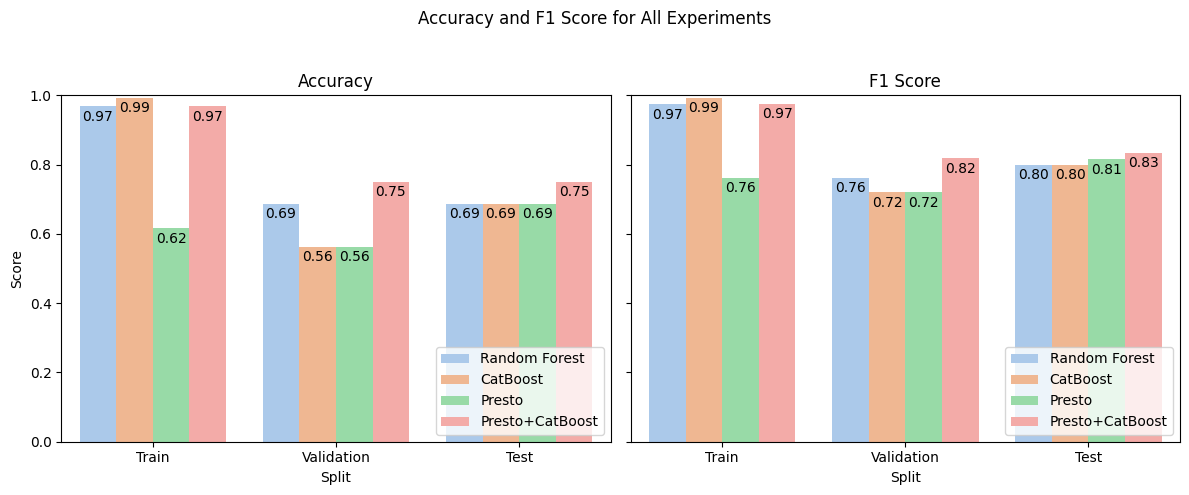

In [117]:
from sklearn.metrics import accuracy_score, f1_score

# Prepare predictions and labels for each experiment
experiments = {
    "Random Forest": (preds_train_rf, preds_val_rf, preds_test_rf),
    "CatBoost": (preds_train_cb, preds_val_cb, preds_test_cb),
    "Presto": (train_preds_presto, val_preds_presto, preds_presto),
    "Presto+CatBoost": (preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb),
}

splits = [("Train", y_train), ("Validation", y_val), ("Test", y_test)]

metrics = []
for exp_name, (train_pred, val_pred, test_pred) in experiments.items():
    preds = [train_pred, val_pred, test_pred]
    for (split_name, y_true), y_pred in zip(splits, preds):
        # If predictions are torch tensors, convert to numpy
        if hasattr(y_pred, "detach"):
            y_pred = y_pred.detach().cpu().numpy()
        if hasattr(y_true, "values"):
            y_true = y_true.values
        # For Presto, predictions may be bool, convert to int
        y_pred = y_pred.astype(int)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        metrics.append({
            "Experiment": exp_name,
            "Split": split_name,
            "Accuracy": acc,
            "F1 Score": f1
        })

metrics_df = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for i, metric in enumerate(["Accuracy", "F1 Score"]):
    ax = axes[i]
    sns.barplot(
        data=metrics_df,
        x="Split",
        y=metric,
        hue="Experiment",
        ax=ax,
        palette="pastel"
    )
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    # Add numbers on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f"{height:.2f}", 
                        (p.get_x() + p.get_width() / 2., height - 0.05), 
                        ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.suptitle("Accuracy and F1 Score for All Experiments")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

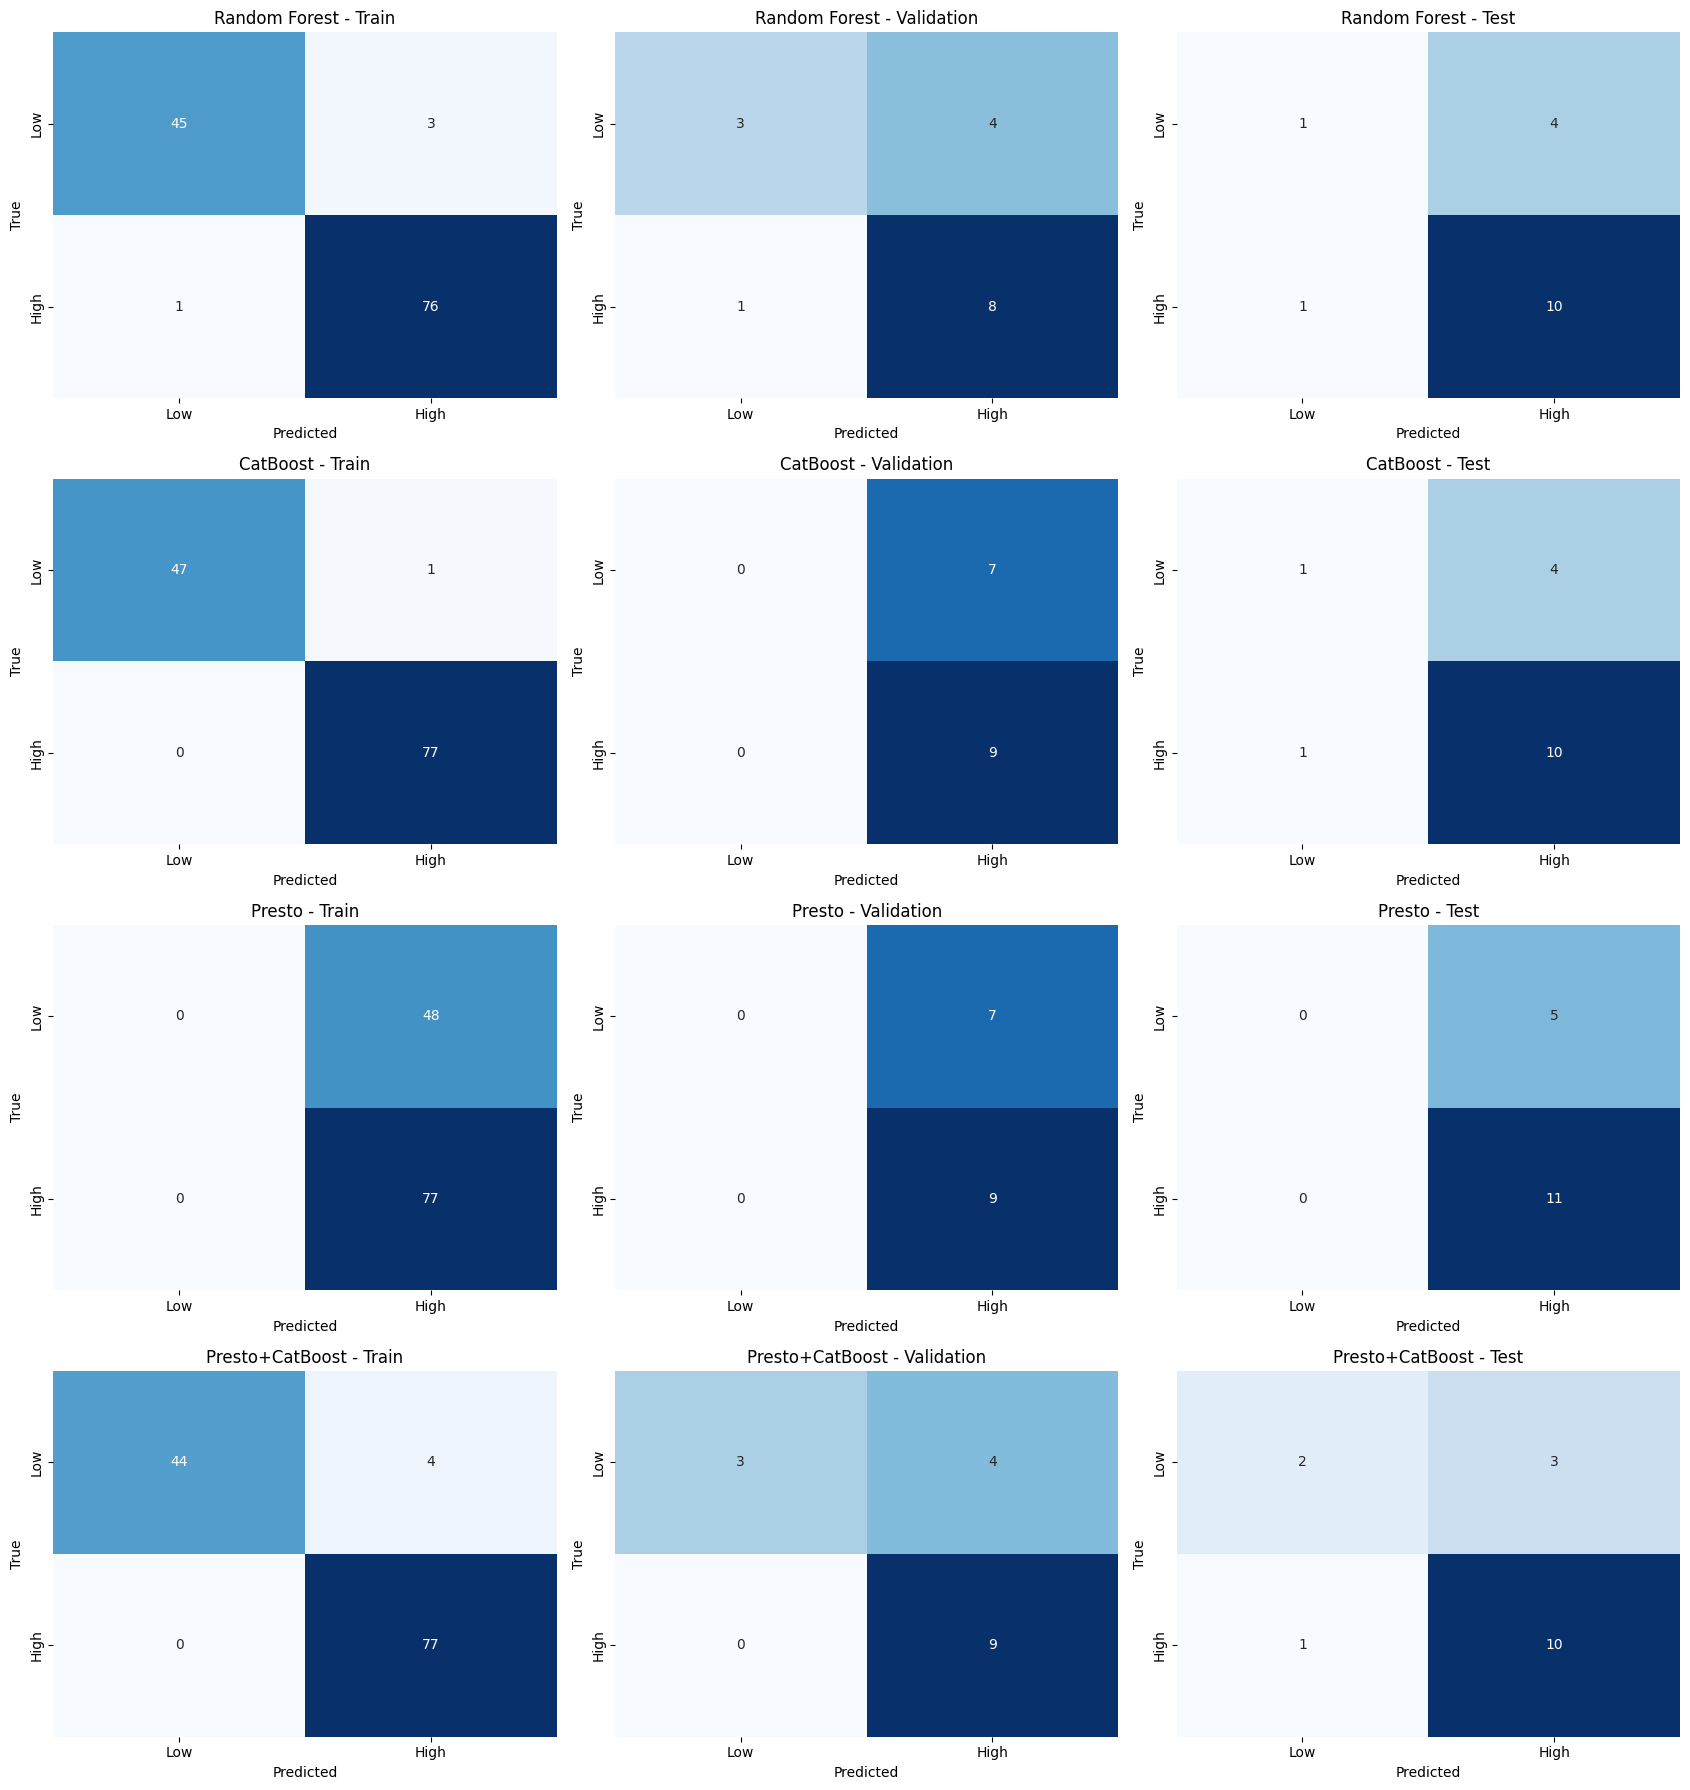

In [127]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare predictions and true labels for each model and split
model_names = ["Random Forest", "CatBoost", "Presto", "Presto+CatBoost"]
split_names = ["Train", "Validation", "Test"]
model_preds = [
    [preds_train_rf, preds_val_rf, preds_test_rf],
    [preds_train_cb, preds_val_cb, preds_test_cb],
    [train_preds_presto.astype(int), val_preds_presto.astype(int), preds_presto.astype(int)],
    [preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb],
]
model_trues = [
    [y_train.values, y_val.values, y_test.values],
    [y_train.values, y_val.values, y_test.values],
    [train_targets_presto, val_targets_presto, targets_presto],
    [train_targets_presto, val_targets_presto, targets_presto],
]

fig, axes = plt.subplots(4, 3, figsize=(17, 18))

for row, model_name in enumerate(model_names):
    for col, split_name in enumerate(split_names):
        y_true = model_trues[row][col]
        y_pred = model_preds[row][col]
        # Convert boolean to int if needed
        if y_pred.dtype == bool:
            y_pred = y_pred.astype(int)
        if y_true.dtype == bool:
            y_true = y_true.astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], cbar=False,
                    xticklabels=["Low", "High"], yticklabels=["Low", "High"])
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('True')
        axes[row, col].set_title(f"{model_name} - {split_name}")

plt.tight_layout()
plt.show()


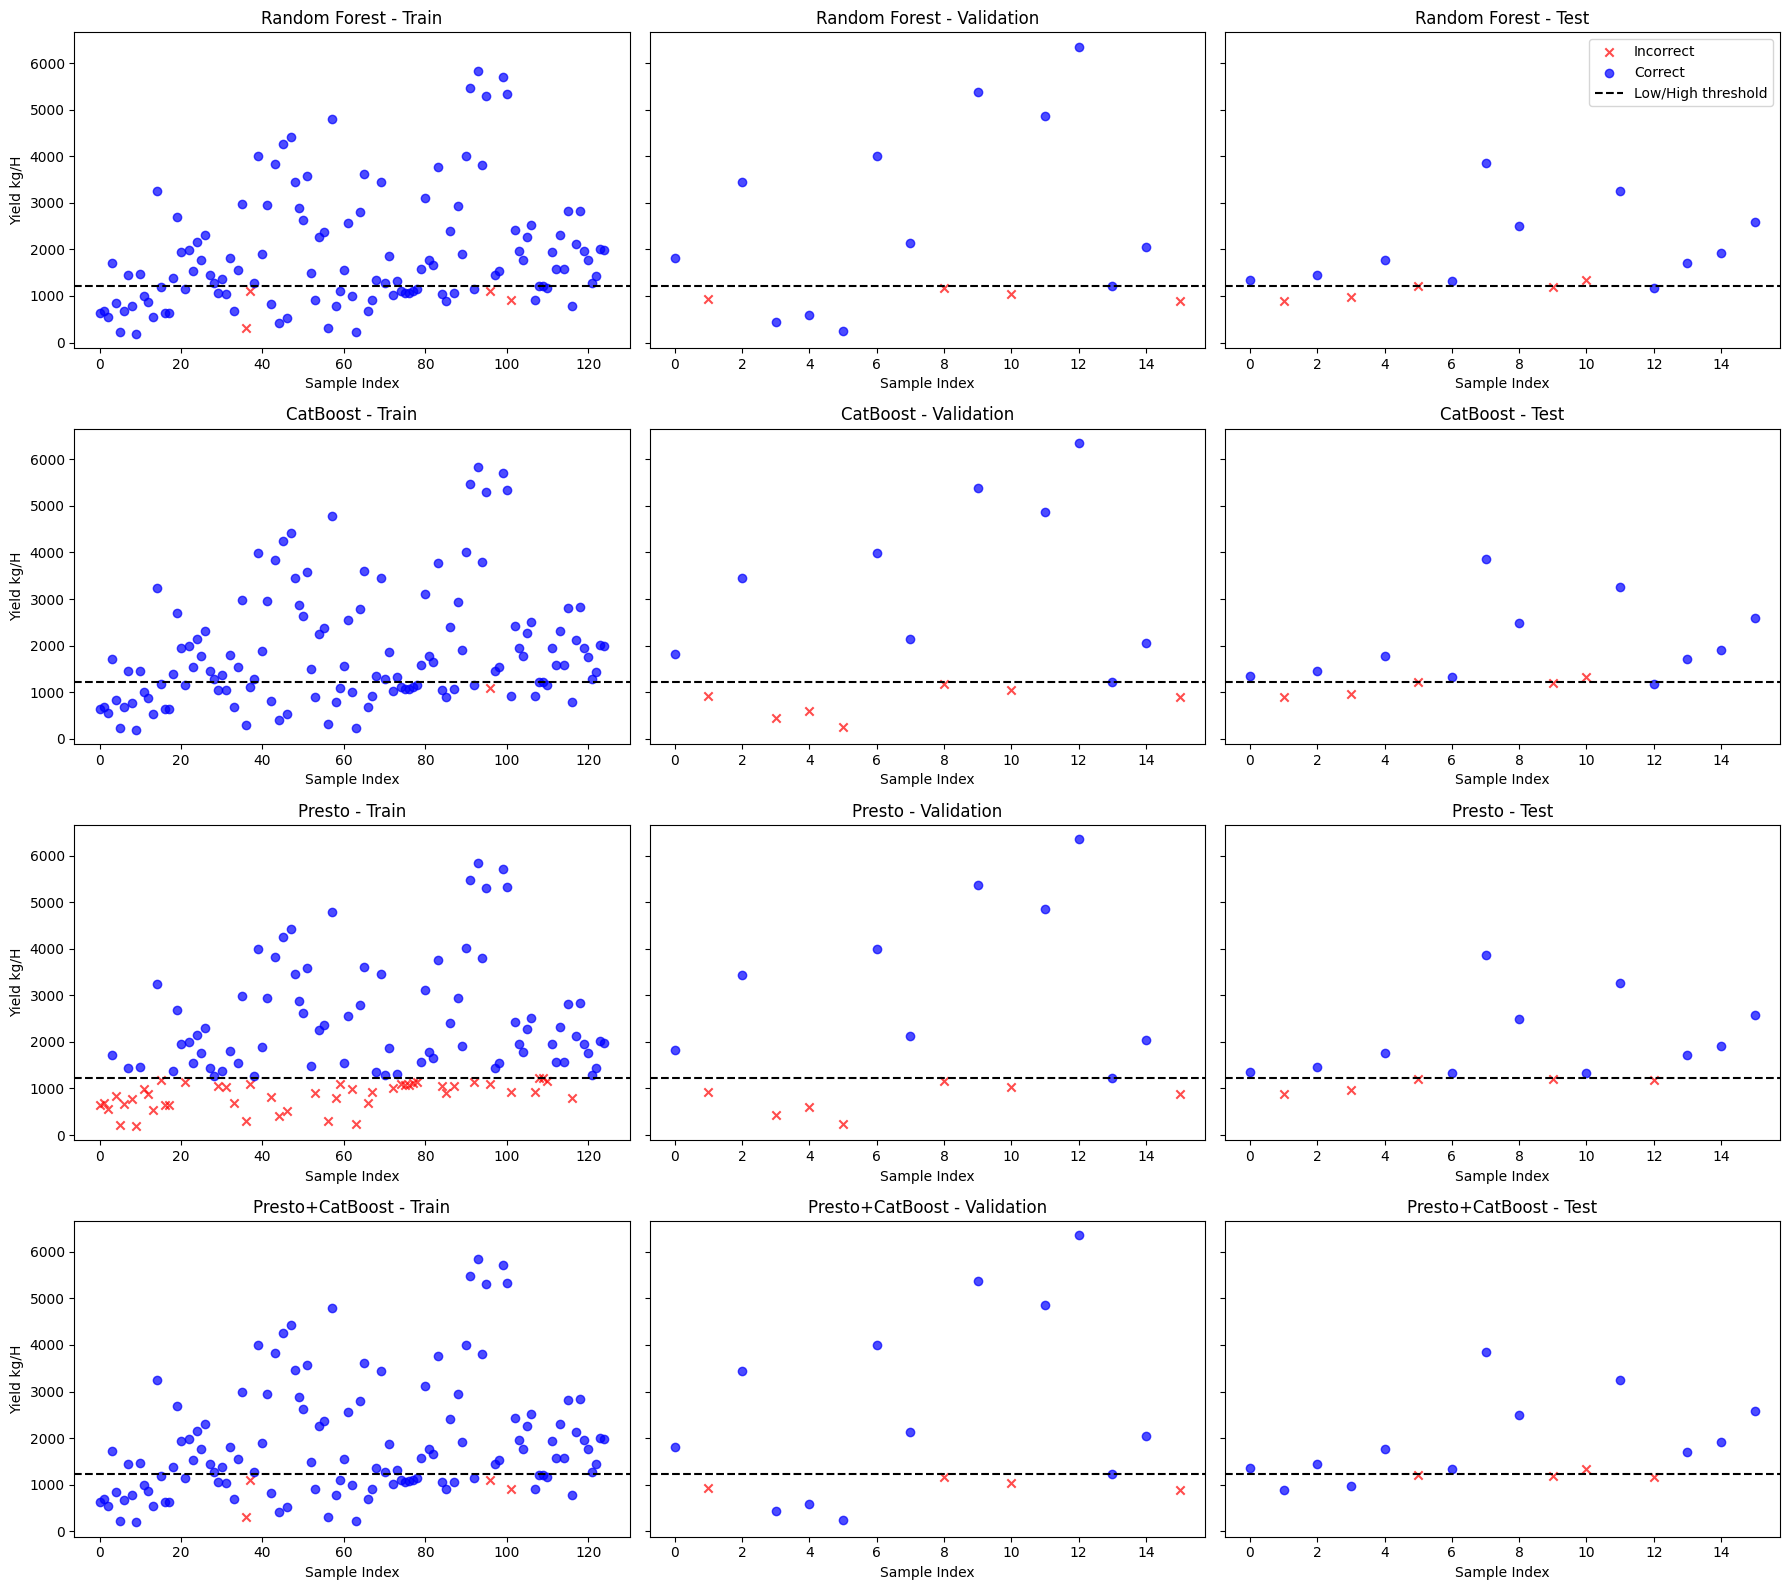

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for plotting
# Each entry: (Model Name, [y_true_train, y_true_val, y_true_test], [y_pred_train, y_pred_val, y_pred_test], [yields_train, yields_val, yields_test])
plot_data = [
    (
        "Random Forest",
        [y_train.values, y_val.values, y_test.values],
        [train_pred, val_pred, preds_test_rf],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "CatBoost",
        [y_train.values, y_val.values, y_test.values],
        [preds_train_cb, preds_val_cb, preds_test_cb],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "Presto",
        [train_targets_presto, val_targets_presto, targets_presto],
        [train_preds_presto.astype(int), val_preds_presto.astype(int), preds_presto.astype(int)],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "Presto+CatBoost",
        [train_targets_presto, val_targets_presto, targets_presto],
        [preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
]

col_titles = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=False, sharey=True)

for row, (model_name, y_trues, y_preds, yields) in enumerate(plot_data):
    for col in range(3):
        ax = axes[row, col]
        y_true = y_trues[col]
        y_pred = y_preds[col]
        yield_vals = yields[col]
        correct = (y_true == y_pred)
        # Plot correct in blue, incorrect in red
        ax.scatter(
            np.arange(len(yield_vals))[~correct], yield_vals[~correct], 
            c="red", label="Incorrect", alpha=0.7, marker="x"
        )
        ax.scatter(
            np.arange(len(yield_vals))[correct], yield_vals[correct], 
            c="blue", label="Correct", alpha=0.7, marker="o"
        )
        # Draw the bin threshold line and always show its label in the legend
        ax.axhline(bin_th, color="black", linestyle="--", label="Low/High threshold")
        ax.set_title(f"{model_name} - {col_titles[col]}")
        ax.set_xlabel("Sample Index")
        if col == 0:
            ax.set_ylabel("Yield kg/H")
        if row == 0 and col == 2:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [132]:
print("TRAIN SET REPORTS")
print("\n")
print("Classification Report for Random Forest on Train Set:")
print("================================================================")
print(classification_report(y_train, preds_train_rf, target_names=["Low Yield", "High Yield"]))
print("Classification Report for CatBoost on Train Set:")
print("================================================================")
print(classification_report(y_train, preds_train_cb, target_names=["Low Yield", "High Yield"]))
print("Classification Report for Presto on Train Set:")
print("================================================================")
print(classification_report(y_train, train_preds_presto, target_names=["Low Yield", "High Yield"]))
print("Classification Report for Presto+CatBoost on Train Set:")
print(classification_report(y_train, preds_train_presto_cb, target_names=["Low Yield", "High Yield"]))
print("\n\n")
print("VALIDATION SET REPORTS")
print("\n")
print("Classification Report for Random Forest on Val Set:")
print("================================================================")
print(classification_report(y_val, preds_val_rf, target_names=["Low Yield", "High Yield"]))
print("Classification Report for CatBoost on Val Set:")
print("================================================================")
print(classification_report(y_val, preds_val_cb, target_names=["Low Yield", "High Yield"]))
print("Classification Report for Presto on Val Set:")
print("================================================================")
print(classification_report(y_val, val_preds_presto, target_names=["Low Yield", "High Yield"]))
print("Classification Report for Presto+CatBoost on Val Set:")
print(classification_report(y_val, preds_val_presto_cb, target_names=["Low Yield", "High Yield"]))
print("\n\n")
print("TEST SET REPORTS")
print("\n")
print("Classification Report for Random Forest on Test Set:")
print("================================================================")
print(classification_report(y_test, preds_test_rf, target_names=["Low Yield", "High Yield"]))
print("Classification Report for CatBoost on Test Set:")
print("================================================================")
print(classification_report(y_test, preds_test_cb, target_names=["Low Yield", "High Yield"]))
print("Classification Report for Presto on Test Set:")
print("================================================================")
print(classification_report(y_test, preds_presto, target_names=["Low Yield", "High Yield"]))
print("Classification Report for Presto+CatBoost on Test Set:")
print(classification_report(y_test, preds_test_presto_cb, target_names=["Low Yield", "High Yield"]))


TRAIN SET REPORTS


Classification Report for Random Forest on Train Set:
              precision    recall  f1-score   support

   Low Yield       0.98      0.94      0.96        48
  High Yield       0.96      0.99      0.97        77

    accuracy                           0.97       125
   macro avg       0.97      0.96      0.97       125
weighted avg       0.97      0.97      0.97       125

Classification Report for CatBoost on Train Set:
              precision    recall  f1-score   support

   Low Yield       1.00      0.98      0.99        48
  High Yield       0.99      1.00      0.99        77

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125

Classification Report for Presto on Train Set:
              precision    recall  f1-score   support

   Low Yield       0.00      0.00      0.00        48
  High Yield       0.62      1.00      0.76        77

    accuracy

/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le